In [1]:
import numpy as np
import timeit
import viscid
import os
from scipy.special import iv

argsdict=viscid.argsdict
from scipy.linalg import eig
from scipy.interpolate import interp1d
from scipy.optimize import minimize_scalar

import matplotlib.pyplot as plt
import json
colors = [
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c",
    "#d62728",
    "#9467bd",
    "#8c564b",
    "#e377c2",
    "#7f7f7f",
    "#bcbd22",
    "#17becf",
]

s=5
s2=0.2
admax=5.0
dfreq=10.0
eta=1E-6
argsdict['dim']=2
argsdict['Nx']=3
argsdict['Ny']=3
argsdict['Nt']=3
argsdict['k1x']=np.pi*s
argsdict['k1y']=0
argsdict['k2x']=-np.pi*s/2
argsdict['k2y']=3**0.5*s/2*np.pi
argsdict['h0']=1.0*s2
argsdict['As']=0.75*s2
num=50

argsdict['k1x']=np.pi*s
argsdict['k1y']=0
argsdict['k2x']=-np.pi*s/2
argsdict['k2y']=3**0.5*s/2*np.pi
kxs1=np.arange(1,num+1)/num*argsdict['k1x']/2
kys1=np.arange(1,num+1)/num*0
kxs2=argsdict['k1x']/2+np.arange(1,num+1)/num*((2*argsdict['k1x'] + argsdict['k2x'])/3 - argsdict['k1x']/2)
kys2=argsdict['k1y']/2+np.arange(1,num+1)/num*((2*argsdict['k1y'] + argsdict['k2y'])/3 - argsdict['k1y']/2)
kxs3=np.arange(1,num)/num*((2*argsdict['k1x'] + argsdict['k2x'])/3)
kys3=np.arange(1,num)/num*((2*argsdict['k1y'] + argsdict['k2y'])/3)
ks=np.concatenate([np.transpose([kxs1[-20::4],kys1[-20::4]]),np.transpose([kxs2[::8],kys2[::8]])])
k0=kxs1[-20]

argsdict['rho']=1.0
argsdict['sigma']=20
argsdict['mu']=20/100

Fluid depth in cm

In [2]:
argsdict['h0']

0.2

Substrate amplitude in cm

In [3]:
argsdict['As']

0.15000000000000002

Substrate wavelength in cm

In [4]:
2*np.pi/argsdict['k1x']

0.4

### Viscid instability boundary

In [5]:
argsdict['ad']=0
argsdict['kx']=k0
argsdict['ky']=0
argsdict['verbose']=1
argsdict['dsmin']=1E-4


def mat0(omega,argsdict):
        E,F=viscid.viscid_mat2d(omega,argsdict)
        shape=E.shape
        E_shaped=E.reshape((3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1,3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1))
        F_shaped=F.reshape((3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1,3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1))

        return (np.tensordot(E_shaped,argsdict['preconditioner'],axes=argsdict['precondition_axes'])-argsdict['ad']*np.tensordot(F_shaped,argsdict['preconditioner'],axes=argsdict['precondition_axes'])).transpose(argsdict['precondition_order']).reshape(shape).T
def mat3(omega,argsdict):
        E,F=viscid.viscid_mat2d(omega,argsdict)
        shape=E.shape
        E_shaped=E.reshape((3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1,3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1))
        F_shaped=F.reshape((3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1,3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1))

        return (-np.tensordot(F_shaped,argsdict['preconditioner'],axes=argsdict['precondition_axes'])).transpose(argsdict['precondition_order']).reshape(shape).T

def mat(ad,argsdict):
    E,F=viscid.viscid_mat2d(2*np.pi*argsdict['freq']/2,argsdict)
    shape=E.shape
    E_shaped=E.reshape((3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1,3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1))
    F_shaped=F.reshape((3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1,3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1))

    return (np.tensordot(E_shaped,argsdict['preconditioner'],axes=argsdict['precondition_axes'])-ad*np.tensordot(F_shaped,argsdict['preconditioner'],axes=argsdict['precondition_axes'])).transpose(argsdict['precondition_order']).reshape(shape).T
def mat2(ad,argsdict):
    E,F=viscid.viscid_mat2d(2*np.pi*argsdict['freq']/2,argsdict)
    shape=E.shape
    E_shaped=E.reshape((3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1,3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1))
    F_shaped=F.reshape((3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1,3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1))

    return (-np.tensordot(F_shaped,argsdict['preconditioner'],axes=argsdict['precondition_axes'])).transpose(argsdict['precondition_order']).reshape(shape).T

Find the starting critical eigenvalues and eigenvectors by continuing the driving amplitude and finding the critical value at fixed frequency and wavenumber

In [6]:
argsdict['kx']=k0
argsdict['ky']=0
F,G=viscid.inviscid_mat_undriven(argsdict)
Ginv=np.linalg.inv(G)
evals,revecs,levecs=eig(Ginv.dot(F).astype(complex),right=True,left=True)
order=np.argsort(np.real(evals))
#we use an initial driving frequency of 90% of the inviscid resonant frequency because the viscid resonances are smaller
freq0s=np.real(0.9*evals[order[:2]]**0.5/(2*np.pi/2)) 
print(freq0s)

F,G=viscid.inviscid_mat_undriven(argsdict)
Ginv=np.linalg.inv(G)
evals,revecs,levecs=eig(Ginv.dot(F).astype(complex),right=True,left=True)
order=np.argsort(evals)

argsdict['verbose']=2
argsdict['lambdamax']=np.inf
ds=5E-1
dsmax=5E-1
argsdict['itmax']=10
argsdict['ds']=ds
argsdict['dsmax']=dsmax
argsdict['dsmin']=1E-3
argsdict['epsl']=1E-3
argsdict['epsu']=1E-3
argsdict['epstp']=5E0
argsdict['thmu']=5E0
argsdict['thl']=5E-1

np.random.seed(1)


ads01=[]
ads02=[]
ads03=[]
vs01=[]
vs02=[]
vs03=[]
ws01=[]
ws02=[]
ws03=[]
omegas01=[]
omegas02=[]
omegas03=[]
dirs01=[]

load=True
overwrite=False

start=timeit.default_timer()
for j in range(2):
    if not os.path.exists('data/experiment/%iads01.npy'%(j)) or not load:
        omega=evals[order[j]]**0.5+1j*0
        E,F=viscid.viscid_mat2d(omega,argsdict)

        v=np.zeros((3,(2*argsdict['Nt']+1),(2*argsdict['Nx']+1),(2*argsdict['Ny']+1)),np.complex128)
        w=np.zeros((3,(2*argsdict['Nt']+1),(2*argsdict['Nx']+1),(2*argsdict['Ny']+1)),np.complex128)
        v[2,argsdict['Nt']]=(revecs[:,order[j]].dot(Ginv)/np.linalg.norm(revecs[:,order[j]].dot(Ginv))).reshape((2*argsdict['Nx']+1,2*argsdict['Ny']+1))
        w[2,argsdict['Nt']]=levecs[:,order[j]].reshape((2*argsdict['Nx']+1,2*argsdict['Ny']+1))
        v=v.ravel()
        w=w.ravel()

        freq0=freq0s[j]
        omega=evals[order[j]]**0.5+1j*0
        argsdict['freq']=freq0
        argsdict['ad']=0

        lps,ls,mps,ms,nps,ns=viscid.makeindices(argsdict)
        kappax = (argsdict['kx'] + argsdict['k1x']*ms + argsdict['k2x']*ns)
        kappay = (argsdict['ky'] + argsdict['k1y']*ms + argsdict['k2y']*ns)
        kappa = (kappax**2+kappay**2)**0.5
        kappapx = (argsdict['kx'] + argsdict['k1x']*mps + argsdict['k2x']*nps)
        kappapy = (argsdict['ky'] + argsdict['k1y']*mps + argsdict['k2y']*nps)
        S = (- np.exp(-kappa*argsdict['h0']) * iv(ms-mps, kappa*argsdict['As']*0.5) * iv(ns-nps, kappa*argsdict['As']*0.5) + np.exp(kappa*argsdict['h0']) * iv(ms-mps, -kappa*argsdict['As']*0.5) * iv(ns-nps, -kappa*argsdict['As']*0.5))
        C = (np.exp(-kappa*argsdict['h0']) * iv(ms-mps, kappa*argsdict['As']*0.5) * iv(ns-nps, kappa*argsdict['As']*0.5) + np.exp(kappa*argsdict['h0']) * iv(ms-mps, -kappa*argsdict['As']*0.5) * iv(ns-nps, -kappa*argsdict['As']*0.5))

        #right preconditioner
        shape_flat=((2*argsdict['Nx']+1)*(2*argsdict['Ny']+1),(2*argsdict['Nx']+1)*(2*argsdict['Ny']+1))
        shape2=((2*argsdict['Nx']+1),(2*argsdict['Ny']+1),(2*argsdict['Nx']+1),(2*argsdict['Ny']+1))
        A2=argsdict['g']*(argsdict['rho']**2*(kappax*kappapx+kappay*kappapy)/kappa*S)
        argsdict['preconditioner']=np.linalg.inv(A2.reshape(shape_flat)).reshape(shape2)

        argsdict['precondition_axes']=((6,7),(0,1))
        argsdict['precondition_order']=(0,1,2,3,4,5,6,7)


        #starting frequency and driving
        omegas,vs,ws=viscid.rayleigh_mat(omega,v,np.conjugate(w),mat0,argsdict)
        omega0=omegas[-1]
        v0=vs[-1]
        w0=ws[-1]
        print(freq0,omegas[-1]/np.pi)
        argsdict['par']='ad'
        argsdict['pari']=0
        argsdict['parf']=admax
        argsdict['ds']=ds
        argsdict['dsmax']=dsmax
        omegas,vs,ws,pars,dirs,dss=viscid.pseudocont(omega0,v0,w0,mat0,argsdict,mat3=mat3)
        omegas01=omegas01+[omegas]
        vs01=vs01+[vs]
        ws01=ws01+[ws]
        ads01=ads01+[pars]
        dirs01=dirs01+[dirs]
        plt.plot(ads01[j],np.real(omegas01[j])/(2*np.pi*freq0s[j]),c=colors[0], marker='o', ms=5)
        plt.show()
        
        ind=np.argmax(pars)
        fomega=interp1d(np.arange(len(omegas)),omegas,kind='cubic')
        fv=interp1d(np.arange(len(omegas)),np.array(vs).T,kind='cubic')
        fw=interp1d(np.arange(len(omegas)),np.array(ws).T,kind='cubic')
        fpar=interp1d(np.arange(len(omegas)),pars,kind='cubic')
        fdir=interp1d(np.arange(len(omegas)),np.array(dirs).T,kind='cubic')

        if ind<len(pars)-3:
            if pars[ind-2]<pars[ind] and pars[ind+2]<pars[ind]:
                find=minimize_scalar(lambda x: -fpar(x),bracket=(ind-1,ind+1)).x
            else:
                find=minimize_scalar(lambda x: fpar(x),bracket=(ind-1,ind+1)).x
        else:
            find=ind
            
        omega0=complex(fomega(find))
        v0=fv(find)
        w0=fw(find)
        dir0=fdir(find)
        s=3*(2*argsdict['Nt']+1)*(2*argsdict['Nx']+1)*(2*argsdict['Ny']+1)
        newdir=np.zeros(dir0.shape)
        newdir[:s]=dir0[s:2*s]
        newdir[s:2*s]=-dir0[:s]
        newdir[2*s]=dir0[2*s+1]
        newdir[2*s+1]=-dir0[2*s]
        newdir[2*s+2]=2*dir0[2*s+2]
        dir0=newdir
        argsdict['ad']=fpar(find)
        print(ind,argsdict['ad'],omega0)
        argsdict['ds']=ds
        argsdict['dsmax']=dsmax
        omegas,vs,ws,pars,dirs,dss=viscid.pseudocont(omega0,v0,w0,mat0,argsdict,mat3=mat3,dir=dir0)
        omegas02=omegas02+[omegas]
        vs02=vs02+[vs]
        ws02=ws02+[ws]
        ads02=ads02+[pars]
        argsdict['ds']=-ds
        argsdict['ad']=fpar(find)
        omegas,vs,ws,pars,dirs,dss=viscid.pseudocont(omega0,v0,w0,mat0,argsdict,mat3=mat3,dir=dir0)
        argsdict['ds']=-argsdict['ds']
        omegas03=omegas03+[omegas]
        vs03=vs03+[vs]
        ws03=ws03+[ws]
        ads03=ads03+[pars]

        if overwrite:
            np.save('data/experiment/%iomegas01.npy'%(j),omegas01[j])
            np.save('data/experiment/%iads01.npy'%(j),ads01[j])
            np.save('data/experiment/%ivs01.npy'%(j),vs01[j])
            np.save('data/experiment/%iws01.npy'%(j),ws01[j])

            np.save('data/experiment/%iomegas02.npy'%(j),omegas02[j])
            np.save('data/experiment/%iads02.npy'%(j),ads02[j])
            np.save('data/experiment/%ivs02.npy'%(j),vs02[j])
            np.save('data/experiment/%iws02.npy'%(j),ws02[j])

            np.save('data/experiment/%iomegas03.npy'%(j),omegas03[j])
            np.save('data/experiment/%iads03.npy'%(j),ads03[j])
            np.save('data/experiment/%ivs03.npy'%(j),vs03[j])
            np.save('data/experiment/%iws03.npy'%(j),ws03[j])
    else:
        omegas01=omegas01+[np.load('data/experiment/%iomegas01.npy'%(j))]
        ads01=ads01+[np.load('data/experiment/%iads01.npy'%(j))]
        vs01=vs01+[np.load('data/experiment/%ivs01.npy'%(j))]
        ws01=ws01+[np.load('data/experiment/%iws01.npy'%(j))]

        omegas02=omegas02+[np.load('data/experiment/%iomegas02.npy'%(j))]
        ads02=ads02+[np.load('data/experiment/%iads02.npy'%(j))]
        vs02=vs02+[np.load('data/experiment/%ivs02.npy'%(j))]
        ws02=ws02+[np.load('data/experiment/%iws02.npy'%(j))]

        omegas03=omegas03+[np.load('data/experiment/%iomegas03.npy'%(j))]
        ads03=ads03+[np.load('data/experiment/%iads03.npy'%(j))]
        vs03=vs03+[np.load('data/experiment/%ivs03.npy'%(j))]
        ws03=ws03+[np.load('data/experiment/%iws03.npy'%(j))]


stop=timeit.default_timer()
print(stop-start)

[19.42467804 52.27884227]
0.011574388016015291


n=0 dv=2.332876e-02 dw=8.129106e-02 dl=1.758113e-01
n=1 dv=4.798163e-03 dw=7.803180e-03 dl=3.579290e-01
n=2 dv=4.476850e-03 dw=1.663316e-03 dl=1.616749e-01
n=3 dv=1.441087e-03 dw=3.946016e-04 dl=8.075127e-02
n=4 dv=1.677173e-04 dw=1.817051e-04 dl=3.498233e-03
n=5 dv=1.034029e-04 dw=2.050084e-04 dl=1.193020e-05
n=0 dv=1.764460e-04 dw=1.237657e-03 dl=2.965264e-03
n=1 dv=3.540859e-04 dw=3.124819e-03 dl=7.561747e-07
n=2 dv=4.208271e-04 dw=2.174032e-03 dl=1.473884e-07
n=3 dv=4.576386e-04 dw=2.134844e-03 dl=1.489190e-08
n=4 dv=2.331355e-04 dw=1.414666e-03 dl=2.491586e-07
n=5 dv=3.872939e-04 dw=1.427344e-03 dl=4.003356e-07
n=6 dv=3.236930e-04 dw=8.710644e-04 dl=2.439986e-07


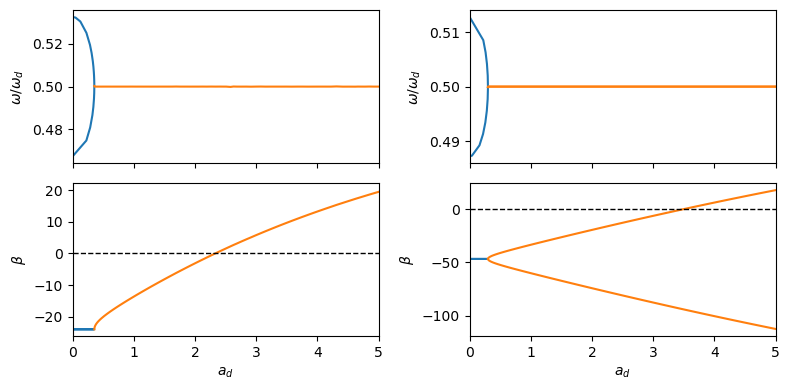

[(2.3293414800341736-3.2645250715947355e-06j), (3.4969734315749084-9.48374967893984e-07j)]


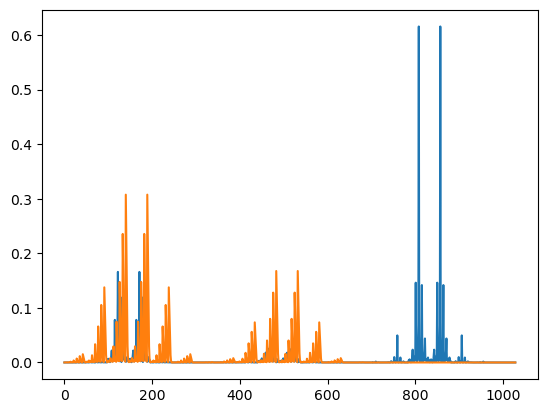

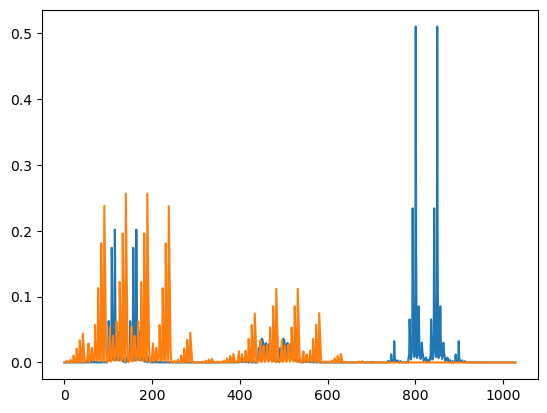

In [7]:
ad0s=[]
vn0s=[]
wn0s=[]
argsdict['epsu']=1E-3

for j in range(2):
    freq0=freq0s[j]
    omega=evals[order[j]]**0.5+1j*0
    argsdict['freq']=freq0
    argsdict['ad']=0

    lps,ls,mps,ms,nps,ns=viscid.makeindices(argsdict)
    kappax = (argsdict['kx'] + argsdict['k1x']*ms + argsdict['k2x']*ns)
    kappay = (argsdict['ky'] + argsdict['k1y']*ms + argsdict['k2y']*ns)
    kappa = (kappax**2+kappay**2)**0.5
    kappapx = (argsdict['kx'] + argsdict['k1x']*mps + argsdict['k2x']*nps)
    kappapy = (argsdict['ky'] + argsdict['k1y']*mps + argsdict['k2y']*nps)
    S = (- np.exp(-kappa*argsdict['h0']) * iv(ms-mps, kappa*argsdict['As']*0.5) * iv(ns-nps, kappa*argsdict['As']*0.5) + np.exp(kappa*argsdict['h0']) * iv(ms-mps, -kappa*argsdict['As']*0.5) * iv(ns-nps, -kappa*argsdict['As']*0.5))
    C = (np.exp(-kappa*argsdict['h0']) * iv(ms-mps, kappa*argsdict['As']*0.5) * iv(ns-nps, kappa*argsdict['As']*0.5) + np.exp(kappa*argsdict['h0']) * iv(ms-mps, -kappa*argsdict['As']*0.5) * iv(ns-nps, -kappa*argsdict['As']*0.5))

    #right preconditioner
    shape_flat=((2*argsdict['Nx']+1)*(2*argsdict['Ny']+1),(2*argsdict['Nx']+1)*(2*argsdict['Ny']+1))
    shape2=((2*argsdict['Nx']+1),(2*argsdict['Ny']+1),(2*argsdict['Nx']+1),(2*argsdict['Ny']+1))
    A2=argsdict['g']*(argsdict['rho']**2*(kappax*kappapx+kappay*kappapy)/kappa*S)
    argsdict['preconditioner']=np.linalg.inv(A2.reshape(shape_flat)).reshape(shape2)

    argsdict['precondition_axes']=((6,7),(0,1))
    argsdict['precondition_order']=(0,1,2,3,4,5,6,7)
        
    argsdict['freq']=freq0s[j]
    ind=np.argmin(np.abs(np.imag(omegas03[j])))
    ad0=ads03[j][ind]
    v0=vs03[j][ind]
    w0=ws03[j][ind]
    if np.min(omegas02[j])<0:
        ind=np.argmin(np.abs(np.imag(omegas02[j])))
        ad0=ads02[j][ind]
        v0=vs02[j][ind]
        w0=ws02[j][ind]
    ads,vs,ws=viscid.rayleigh_mat(ad0,v0,w0,mat,argsdict,mat2)
    ad0s=ad0s+[ads[-1]]
    vn0s=vn0s+[vs[-1]]
    wn0s=wn0s+[ws[-1]]
    
plt.subplots(2,2,figsize=(8,4))

for j in range(2):
    plt.subplot(2,2,j+1)
    plt.plot(ads01[j],np.real(omegas01[j])/(2*np.pi*freq0s[j]),c=colors[0])
    plt.plot(ads02[j],np.real(omegas02[j])/(2*np.pi*freq0s[j]),c=colors[1])
    plt.plot(ads03[j],np.real(omegas03[j])/(2*np.pi*freq0s[j]),c=colors[1])
    plt.xlim(0,admax)

    plt.gca().set_xticks(plt.gca().get_xticks(),['']*len(plt.gca().get_xticks()))
    plt.ylabel(r'$\omega/\omega_d$')

    plt.subplot(2,2,j+3)
    plt.plot(ads01[j],-np.imag(omegas01[j]),c=colors[0])
    plt.plot(ads02[j],-np.imag(omegas02[j]),c=colors[1])
    plt.plot(ads03[j],-np.imag(omegas03[j]),c=colors[1])
    plt.plot([0,admax],[0,0],ls='--',color='black',lw=1)
    plt.ylabel(r'$\beta$')
    plt.xlabel('$a_d$')
    plt.xlim(0,admax)


plt.tight_layout()
plt.show()
print(ad0s)
for j in range(2):
    plt.plot(np.abs(vn0s[j]))
    plt.plot(np.abs(wn0s[j]))
    plt.show()

[[4.86946861 0.        ]
 [5.49778714 0.        ]
 [6.12610567 0.        ]
 [6.75442421 0.        ]
 [7.38274274 0.        ]
 [7.85398163 0.09068997]
 [7.85398163 0.81620971]
 [7.85398163 1.54172946]
 [7.85398163 2.26724921]
 [7.85398163 2.99276895]
 [7.85398163 3.7182887 ]
 [7.85398163 4.44380844]]
12
12.98268636733264 29.633615918377313 18.209234163132237 (2.2919277067973676-1.4252245113755477e-06j)


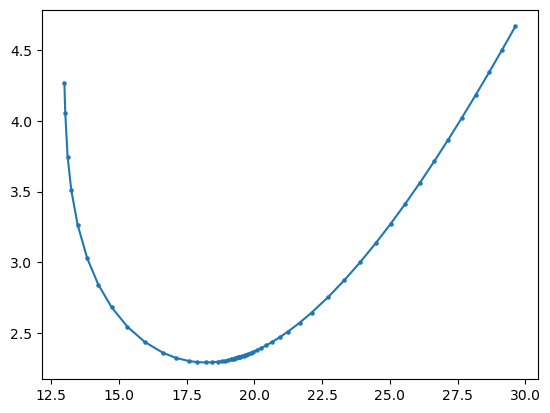

0.11989434895804152
15.204535086741977 28.756851363059553 21.664439736274193 (2.3371662533433173+1.8444464023170049e-06j)


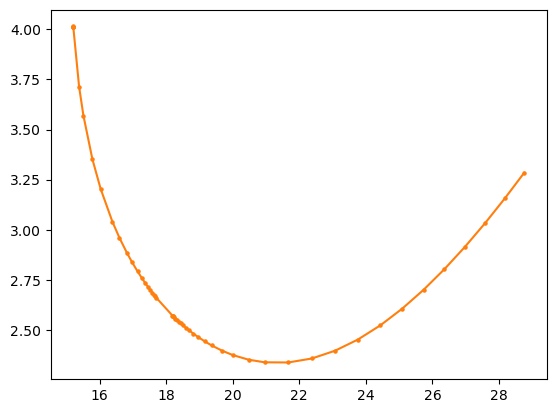

0.2192132209893316
17.452153896825347 31.892365218080375 24.43600267192484 (2.4134325613765815+3.0769736160896164e-06j)


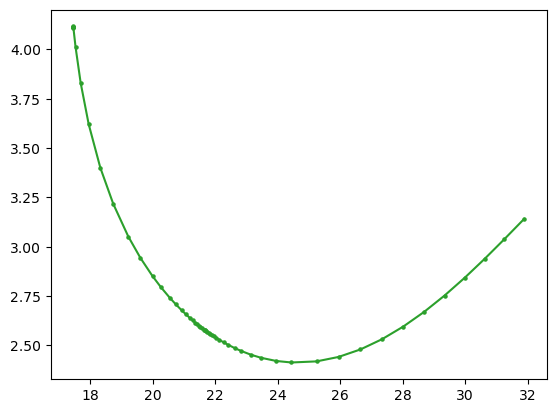

0.31415639200713485
19.466178388423206 35.01421194618197 27.944692426020524 (2.514581855516881-3.564986626612117e-06j)


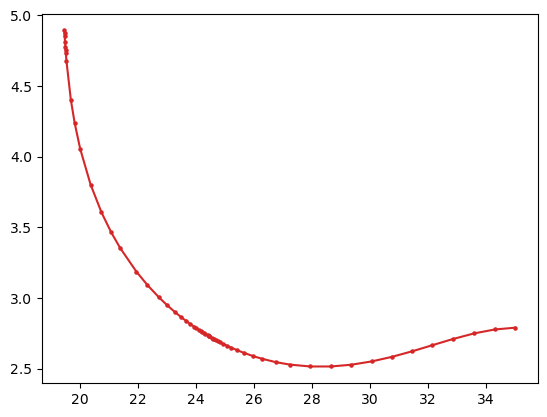

0.39225670299492776
22.076718819979252 38.41188062722115 36.973730690806086 (2.341974727169967+3.3863570150958046e-08j)


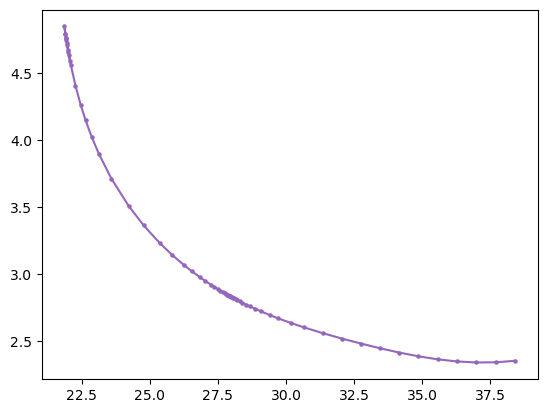

0.4657962449709885
34.449912479506565 47.454475521086955 36.88426521933101 (2.242948413284792+2.5900214034918945e-07j)


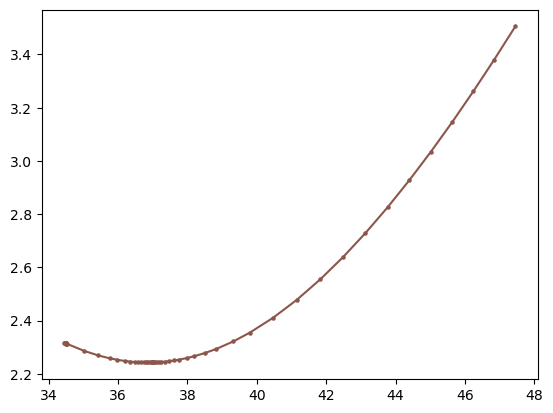

0.5451236189692281
35.05261570113956 47.429650268255976 37.03442530567189 (2.26146746362036-1.9182122819337163e-07j)


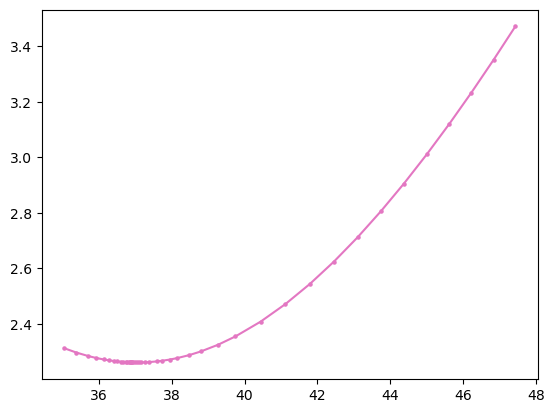

0.618918431981001
30.949426046891663 47.59564037718121 37.514722892864576 (2.3086147883871506+7.369437161245281e-07j)


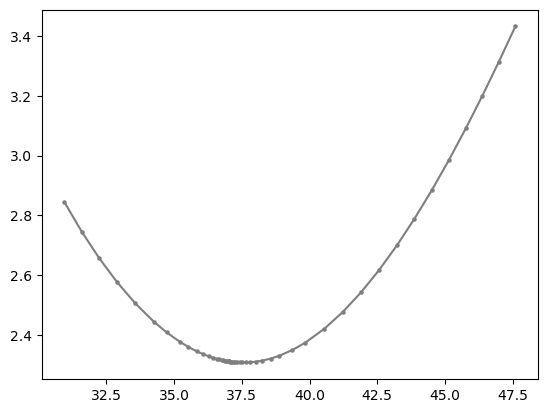

0.695075346971862
29.442848998321608 47.56751202411784 38.264863077438186 (2.383950707151367+2.412590512050274e-07j)


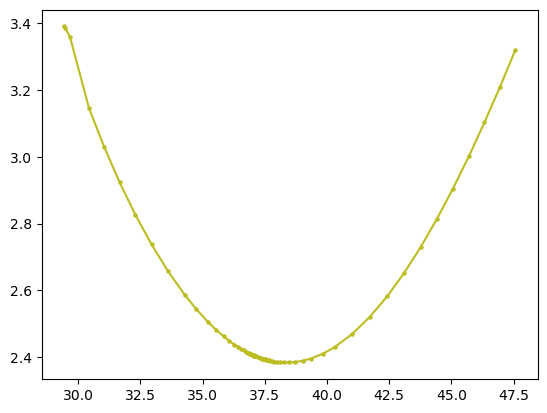

0.7742826199973933
31.443501695476506 48.379875546910036 39.44537207091936 (2.4863058411738077+4.799436582861117e-07j)


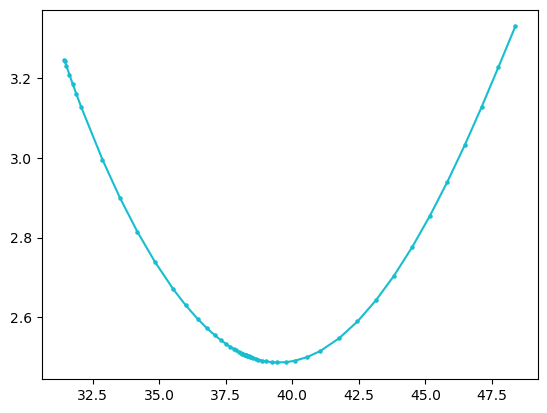

0.862205893965438
32.26999704891098 49.683298936942535 40.94719631796462 (2.6145642304190027-4.8660335436785944e-08j)


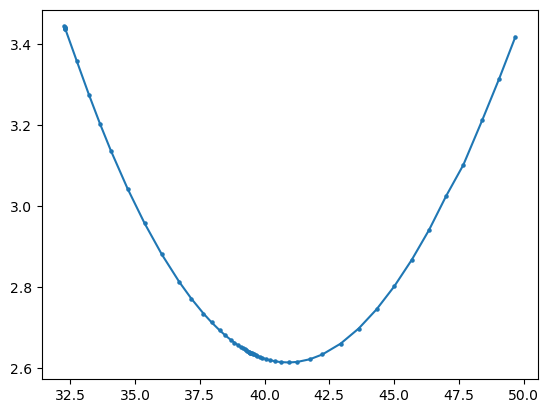

0.9384932639659382
30.678369510922025 43.79278776351936 42.444918137372106 (2.754524247211741+1.3427806647437655e-07j)


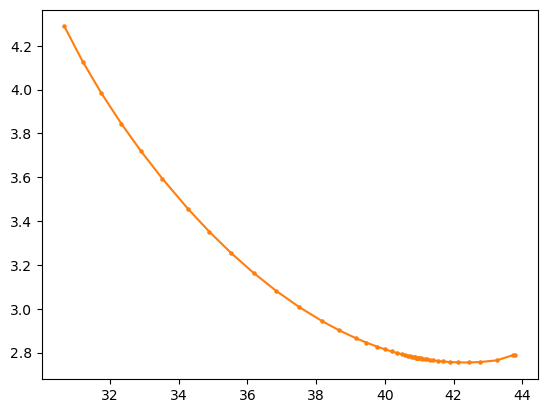

1.0681176309590228
41.71012730448835 62.542662232099445 53.23970560993351 (3.489792681247095-1.353901150981129e-07j)


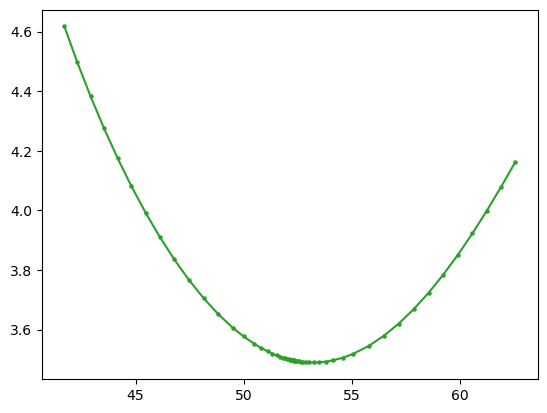

1.1425727659952827
42.83305742278448 63.59764790271233 49.075271303984316 (3.2302052469005873+1.2625238416795332e-09j)


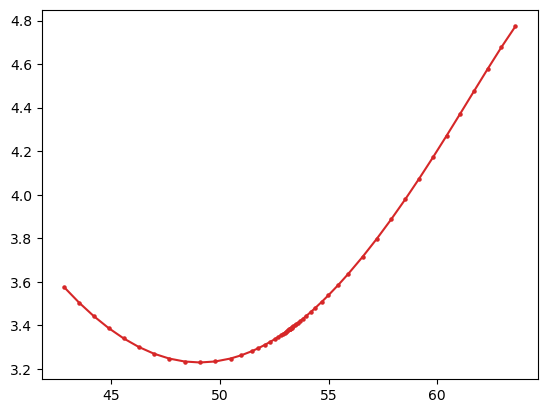

1.223778821004089
38.66116467599468 59.25468730858761 44.914276986556004 (2.9691420084049063-8.567133868943375e-07j)


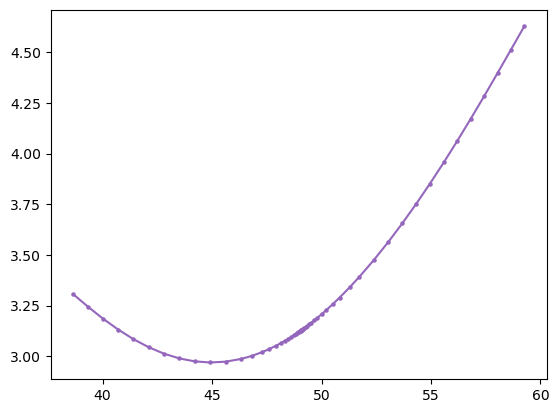

1.3323861680109985
34.40098959790032 54.97795924901549 40.75236696772464 (2.673455341186043-3.4389709283502344e-07j)


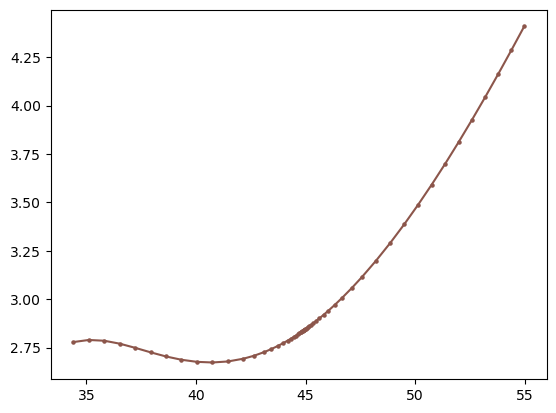

1.4075050299870782
30.272462129034235 50.772787215027684 37.2851192472732 (2.341360666547774+3.737729811876075e-07j)


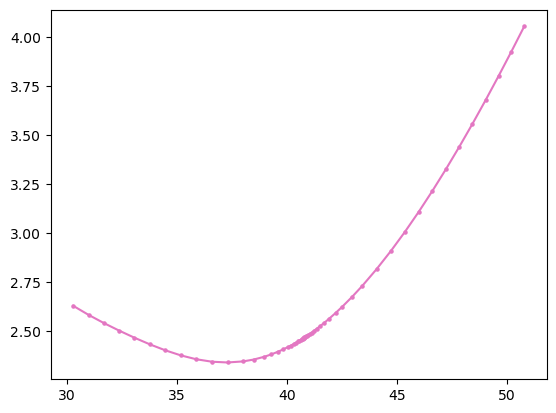

1.4821951829944737
28.142965260190508 47.64931585332937 36.82003132430016 (2.24294416315298-1.0918767239586355e-06j)


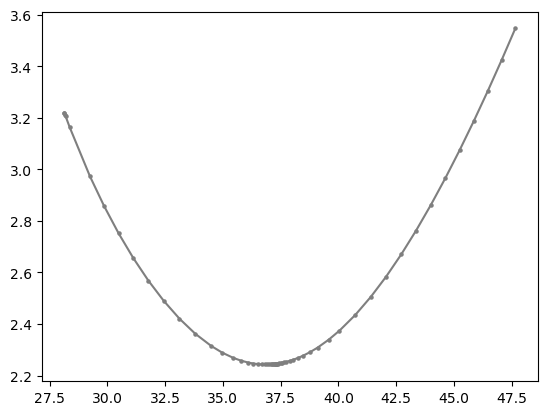

1.5832046199939214
31.350474257627887 47.31852412090867 37.03033666184258 (2.261468431675957-3.3587345480388704e-06j)


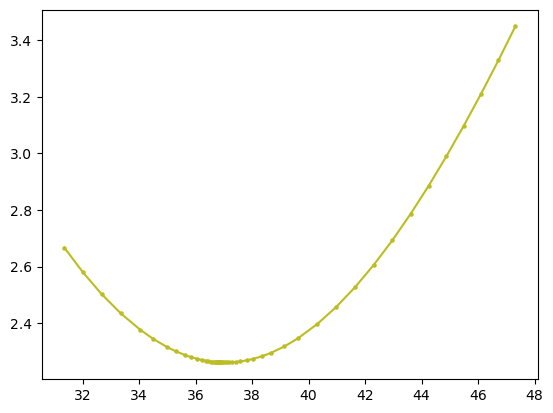

1.6695153400069103
31.654181554241536 47.04625128586011 37.492822243461944 (2.3086413557236654-1.998026197822713e-06j)


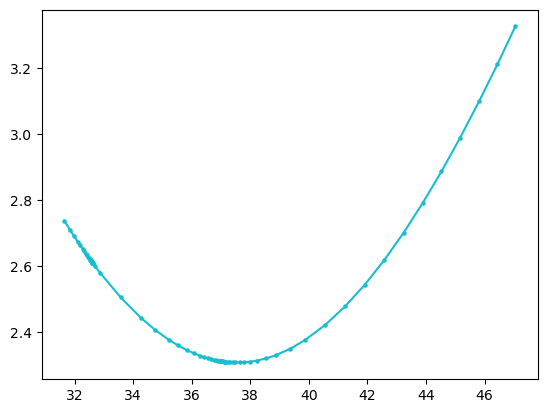

1.7475112639949657
29.478064563825676 47.51279767922715 38.457089014377146 (2.383899835621756-2.398009000988675e-07j)


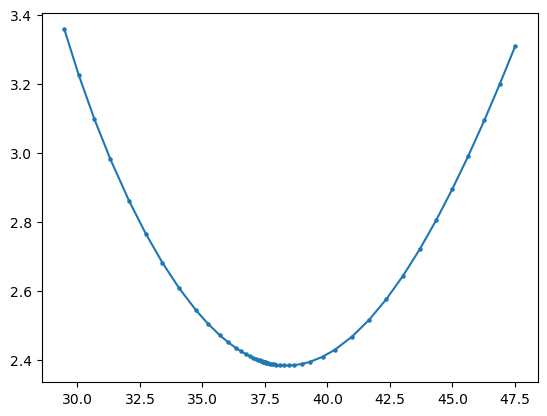

1.8538516279659234
31.66055891011258 48.53479940594446 39.42196658365197 (2.486344010296272+1.0650668954625808e-06j)


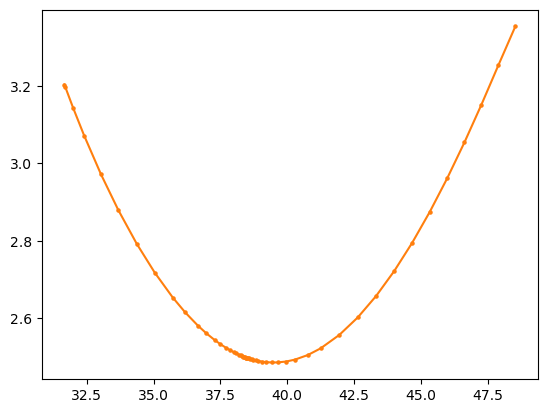

1.92799846699927
32.09316238364688 49.80998958155135 40.91768945319266 (2.614554183301632-1.2213364957918568e-06j)


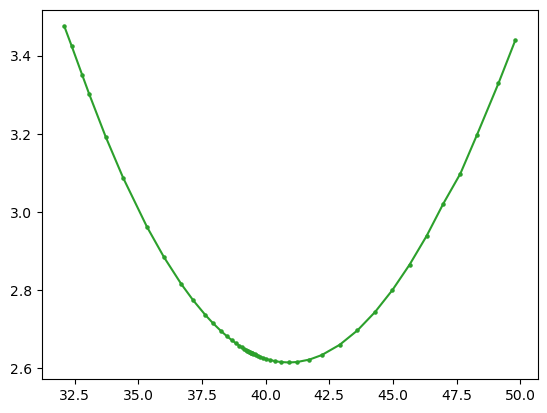

2.00512666098075
34.340495343847294 45.537978167334025 42.427943742268454 (2.7544885260611958-1.9441258503584518e-07j)


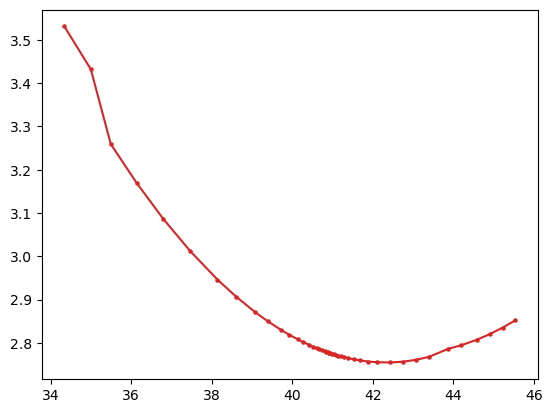

2.0861664509866387


In [8]:
start=timeit.default_timer()
adssweep=[]
freqsweep=[]
vssweep=[]
wssweep=[]
dirsweep=[]
dssweep=[]
argsdict['verbose']=0
argsdict['lambdamax']=admax

ds=5E-1
ds0=2E-2
argsdict['dsmax']=ds
argsdict['ds']=ds0
argsdict['dsmin']=1E-3

argsdict['epsu']=1E-3
argsdict['epsl']=1E-3
argsdict['dmu_fd']=1E-2
argsdict['epstp']=np.inf
# argsdict['epstp']=2E0
argsdict['epstp']=1E0
argsdict['epdir']=np.inf
argsdict['thmu']=5E-1
argsdict['thl']=5E0
argsdict['thu']=1E-3
argsdict['itmax']=10
argsdict['Nsteps']=50
np.random.seed(1)

ks=np.concatenate([np.transpose([kxs1[-20::4],kys1[-20::4]]),np.transpose([kxs2[::8],kys2[::8]])])

print(ks)
print(len(ks))
load=True
overwrite=False

l=0
for j in range(2):
    ad0=ad0s[j]
    vs0=vn0s[j]
    ws0=wn0s[j]
    freq0=freq0s[j]
    
    argsdict['freq']=freq0
    argsdict['kx']=ks[0][0]
    argsdict['ky']=ks[0][1]
    
    lps,ls,mps,ms,nps,ns=viscid.makeindices(argsdict)
    kappax = (argsdict['kx'] + argsdict['k1x']*ms + argsdict['k2x']*ns)
    kappay = (argsdict['ky'] + argsdict['k1y']*ms + argsdict['k2y']*ns)
    kappa = (kappax**2+kappay**2)**0.5
    kappapx = (argsdict['kx'] + argsdict['k1x']*mps + argsdict['k2x']*nps)
    kappapy = (argsdict['ky'] + argsdict['k1y']*mps + argsdict['k2y']*nps)
    S = (- np.exp(-kappa*argsdict['h0']) * iv(ms-mps, kappa*argsdict['As']*0.5) * iv(ns-nps, kappa*argsdict['As']*0.5) + np.exp(kappa*argsdict['h0']) * iv(ms-mps, -kappa*argsdict['As']*0.5) * iv(ns-nps, -kappa*argsdict['As']*0.5))
    C = (np.exp(-kappa*argsdict['h0']) * iv(ms-mps, kappa*argsdict['As']*0.5) * iv(ns-nps, kappa*argsdict['As']*0.5) + np.exp(kappa*argsdict['h0']) * iv(ms-mps, -kappa*argsdict['As']*0.5) * iv(ns-nps, -kappa*argsdict['As']*0.5))

    #right preconditioner
    shape_flat=((2*argsdict['Nx']+1)*(2*argsdict['Ny']+1),(2*argsdict['Nx']+1)*(2*argsdict['Ny']+1))
    shape2=((2*argsdict['Nx']+1),(2*argsdict['Ny']+1),(2*argsdict['Nx']+1),(2*argsdict['Ny']+1))
    A2=argsdict['g']*(argsdict['rho']**2*(kappax*kappapx+kappay*kappapy)/kappa*C)
    argsdict['preconditioner']=np.linalg.pinv(A2.reshape(shape_flat)).reshape(shape2)

    argsdict['precondition_axes']=((6,7),(0,1))
    argsdict['precondition_order']=(0,1,2,3,4,5,6,7)

    for i in range(len(ks)):
        if not os.path.exists('data/experiment/%iads.npy'%(l)) or not load:
            kx=ks[i][0]
            ky=ks[i][1]

            print(i,freq0,kx,ky)
            argsdict['freq']=freq0
            if(argsdict['kx']!=kx):
                argsdict['par']='kx'
                argsdict['pari']=np.min([kx,argsdict['kx']])
                argsdict['parf']=np.max([kx,argsdict['kx']])

                argsdict['ds']=np.sign(kx-argsdict['kx'])*1E-4
                ads1,vs1,ws1,pars1,dirs1,dss1=viscid.pseudocont(ad0, vs0, ws0, mat, argsdict, mat2)
                argsdict['kx']=kx
                ads1,vs1,ws1=viscid.rayleigh_mat(ads1[-1], vs1[-1], ws1[-1], mat, argsdict, mat2)
                ad0=ads1[-1]
                vs0=vs1[-1]
                ws0=ws1[-1]
            if(argsdict['ky']!=ky):
                argsdict['par']='ky'
                argsdict['pari']=np.min([ky,argsdict['ky']])
                argsdict['parf']=np.max([ky,argsdict['ky']])

                argsdict['ds']=np.sign(ky-argsdict['ky'])*1E-4
                ads1,vs1,ws1,pars1,dirs1,dss1=viscid.pseudocont(ad0, vs0, ws0, mat, argsdict, mat2)
                argsdict['ky']=ky
                ads1,vs1,ws1=viscid.rayleigh_mat(ads1[-1], vs1[-1], ws1[-1], mat, argsdict, mat2)
                ad0=ads1[-1]
                vs0=vs1[-1]
                ws0=ws1[-1]

            lps,ls,mps,ms,nps,ns=viscid.makeindices(argsdict)
            kappax = (argsdict['kx'] + argsdict['k1x']*ms + argsdict['k2x']*ns)
            kappay = (argsdict['ky'] + argsdict['k1y']*ms + argsdict['k2y']*ns)
            kappa = (kappax**2+kappay**2)**0.5
            kappapx = (argsdict['kx'] + argsdict['k1x']*mps + argsdict['k2x']*nps)
            kappapy = (argsdict['ky'] + argsdict['k1y']*mps + argsdict['k2y']*nps)
            S = (- np.exp(-kappa*argsdict['h0']) * iv(ms-mps, kappa*argsdict['As']*0.5) * iv(ns-nps, kappa*argsdict['As']*0.5) + np.exp(kappa*argsdict['h0']) * iv(ms-mps, -kappa*argsdict['As']*0.5) * iv(ns-nps, -kappa*argsdict['As']*0.5))
            C = (np.exp(-kappa*argsdict['h0']) * iv(ms-mps, kappa*argsdict['As']*0.5) * iv(ns-nps, kappa*argsdict['As']*0.5) + np.exp(kappa*argsdict['h0']) * iv(ms-mps, -kappa*argsdict['As']*0.5) * iv(ns-nps, -kappa*argsdict['As']*0.5))

            #right preconditioner
            shape_flat=((2*argsdict['Nx']+1)*(2*argsdict['Ny']+1),(2*argsdict['Nx']+1)*(2*argsdict['Ny']+1))
            shape2=((2*argsdict['Nx']+1),(2*argsdict['Ny']+1),(2*argsdict['Nx']+1),(2*argsdict['Ny']+1))
            A2=argsdict['g']*(argsdict['rho']**2*(kappax*kappapx+kappay*kappapy)/kappa*C)
            argsdict['preconditioner']=np.linalg.pinv(A2.reshape(shape_flat)).reshape(shape2)

            argsdict['precondition_axes']=((6,7),(0,1))
            argsdict['precondition_order']=(0,1,2,3,4,5,6,7)

            argsdict['freq']=freq0
            argsdict['par']='freq'
            argsdict['pari']=freq0-dfreq
            argsdict['parf']=freq0+dfreq

            argsdict['ds']=ds0
            np.random.seed(l)
            ads2,vs2,ws2,pars2,dirs2,dss2=viscid.pseudocont(ad0, vs0, ws0, mat, argsdict, mat2)
            argsdict['freq']=freq0        
            argsdict['ds']=-ds0
            np.random.seed(l)
            ads3,vs3,ws3,pars3,dirs3,dss3=viscid.pseudocont(ad0, vs0, ws0, mat, argsdict, mat2) 
            

            freqsweep=freqsweep+[np.flip(pars3).tolist()+pars2]
            adssweep=adssweep+[np.flip(ads3).tolist()+ads2]
            vssweep=vssweep+[np.flip(vs3,axis=0).tolist()+vs2]
            wssweep=wssweep+[np.flip(ws3,axis=0).tolist()+ws2]
            dirsweep=dirsweep+[np.flip(dirs3,axis=0).tolist()+dirs2]
            dssweep=dssweep+[np.flip(dss3,axis=0).tolist()+dss2]
            if overwrite:
                np.save('data/experiment/%iads.npy'%(l),adssweep[l])
                np.save('data/experiment/%ivs.npy'%(l),vssweep[l])
                np.save('data/experiment/%iws.npy'%(l),wssweep[l])
                np.save('data/experiment/%ifreqs.npy'%(l),freqsweep[l])
                np.save('data/experiment/%idirs.npy'%(l),dirsweep[l])
                np.save('data/experiment/%idss.npy'%(l),dssweep[l])

        else:
            adssweep=adssweep+[np.load('data/experiment/%iads.npy'%(l))]
            vssweep=vssweep+[np.load('data/experiment/%ivs.npy'%(l))]
            wssweep=wssweep+[np.load('data/experiment/%iws.npy'%(l))]
            freqsweep=freqsweep+[np.load('data/experiment/%ifreqs.npy'%(l))]
            dirsweep=dirsweep+[np.load('data/experiment/%idirs.npy'%(l))]
            dssweep=dssweep+[np.load('data/experiment/%idss.npy'%(l))]
            
        ind=np.argmin(np.abs(adssweep[-1]))
        ad0=adssweep[-1][ind]
        vs0=np.array(vssweep[-1][ind])
        ws0=np.array(wssweep[-1][ind])
        freq0=freqsweep[-1][ind]
        print(freqsweep[-1][0],freqsweep[-1][-1],freq0,ad0)
        
        
        plt.plot(freqsweep[l],np.abs(np.real(adssweep[l])),c=colors[l%len(colors)])
        plt.scatter(freqsweep[l],np.abs(np.real(adssweep[l])),c=colors[l%len(colors)],s=5)
        plt.show() 
        
        l=l+1

        stop=timeit.default_timer()
        print(stop-start)


<function matplotlib.pyplot.show(close=None, block=None)>

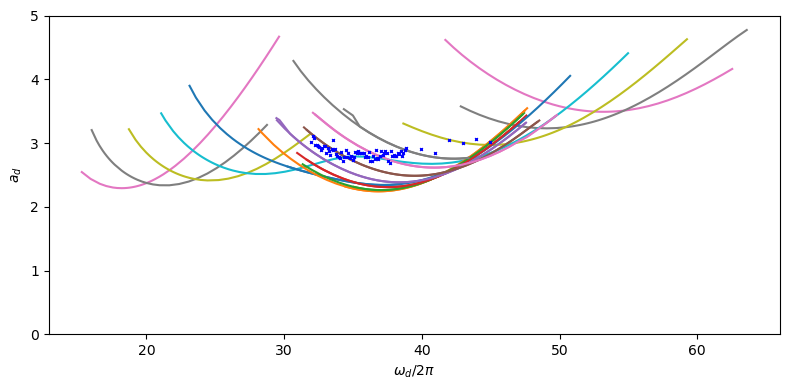

In [9]:
plt.figure(figsize=(8,4))
for i in range(len(ks)):
    inds=np.where(np.abs(np.imag(adssweep[i]))<1E-4)[0]
    plt.plot(np.array(freqsweep[i])[inds],np.abs(np.real(adssweep[i]))[inds],c=colors[(i-4)%len(colors)])
plt.xlabel(r'$\omega_d/2\pi$')
plt.ylabel(r'$a_d$')
plt.ylim(0,20.0)
plt.tight_layout()

for i in range(len(ks)):
    inds=np.where(np.abs(np.imag(adssweep[i+len(ks)]))<1E-4)[0]
    plt.plot(np.array(freqsweep[i+len(ks)])[inds],np.abs(np.real(adssweep[i+len(ks)]))[inds],c=colors[(i-4)%len(colors)],label='$k_x=%.3f, ky=%.3f$'%(ks[i][0],ks[i][1]))


dat=np.loadtxt('data/experiment/t1/t1.txt')
plt.plot(dat[:,2],dat[:,1],'bx',markersize=2.0)

plt.xlabel(r'$\omega_d/2\pi$')
plt.ylabel(r'$a_d$')
plt.ylim(0,admax)
plt.tight_layout()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

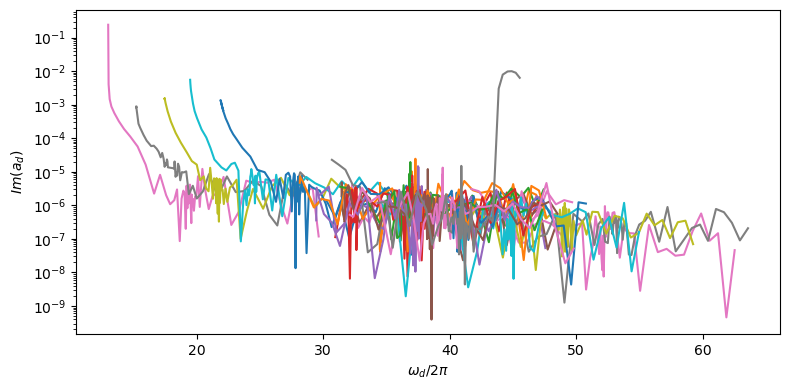

In [10]:
plt.figure(figsize=(8,4))
for i in range(len(ks)):
    plt.plot(np.array(freqsweep[i]),np.abs(np.imag(adssweep[i])),c=colors[(i-4)%len(colors)])
plt.xlabel(r'$\omega_d/2\pi$')
plt.ylabel(r'$a_d$')
# plt.ylim(0,20.0)
plt.tight_layout()

for i in range(len(ks)):
    plt.plot(np.array(freqsweep[i+len(ks)]),np.abs(np.imag(adssweep[i+len(ks)])),c=colors[(i-4)%len(colors)],label='$k_x=%.3f, ky=%.3f$'%(ks[i][0],ks[i][1]))


plt.xlabel(r'$\omega_d/2\pi$')
plt.ylabel(r'$Im(a_d)$')
# plt.ylim(0,admax)
plt.yscale('log')
plt.tight_layout()
plt.show